In [6]:
# import core packages
import warnings
warnings.filterwarnings("ignore")
from itertools import combinations
import os

# import semi-core packages
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import numpy as np
import pandas as pd
from multiprocessing import Pool

# import open2c libraries
import bioframe

import cooler
import cooltools

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorial relies on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

num_cpus = 5

### Load Hi-C cool files (1kb resolution)

In [16]:
clrs = {
    'Adult': cooler.Cooler('/tank/projects/kashuk_sirt6_hic/combined/bal_sampled_Adult_1k.cool'),
    'Old': cooler.Cooler('/tank/projects/kashuk_sirt6_hic/combined/bal_sampled_Old_1k.cool'),
    'S6-KO': cooler.Cooler('/tank/projects/kashuk_sirt6_hic/combined/bal_sampled_S6-KO_1k.cool')
}


### Load chromosome arms data

In [3]:
mm10_arms = pd.read_csv('mm10_arms.csv', index_col=0)
mm10_arms.head(5)

,chrom,start,end,name
0,chr1,0,195471971,chr1_p
1,chr2,0,182113224,chr2_p
2,chr3,0,160039680,chr3_p
3,chr4,0,156508116,chr4_p
4,chr5,0,151834684,chr5_p


### Calculate expected interactions per chromosome arm and aggregate scaling data

In [17]:
colors = {'Adult': 'tan', 'Old': 'sienna', 'S6-KO': 'grey'}

cvd_results = {}
slopes = {}

def process_cooler(clr, name):
    """Process Hi-C data to compute expected contacts and store results."""
    cvd_smooth_agg = cooltools.expected_cis(
        clr=clr,
        view_df=mm10_arms,
        smooth=True,
        aggregate_smoothed=True,
        smooth_sigma=0.1,
        nproc=num_cpus
    )
    
    cvd_smooth_agg['balanced.avg.smoothed.agg'].loc[cvd_smooth_agg['dist'] < 2] = np.nan
    cvd_merged = cvd_smooth_agg.drop_duplicates(subset=['dist'])[['dist_bp', 'balanced.avg.smoothed.agg']]
    cvd_results[name] = cvd_merged
    
    # Compute slope
    slopes[name] = np.gradient(np.log(cvd_merged['balanced.avg.smoothed.agg']), np.log(cvd_merged['dist_bp']))


In [18]:
for name, clr in clrs.items():
    process_cooler(clr, name)

INFO:root:creating a Pool of 5 workers
INFO:root:creating a Pool of 5 workers
INFO:root:creating a Pool of 5 workers


In [19]:
import pandas as pd

combined_df = pd.concat(
    [df.assign(condition=name) for name, df in cvd_results.items()],
    ignore_index=True
)

In [20]:
combined_df.head(5)

,dist_bp,balanced.avg.smoothed.agg,condition
0,0,NaN,Adult
1,1000,NaN,Adult
2,2000,0.003212,Adult
3,3000,0.002999,Adult
4,4000,0.002757,Adult


In [21]:
%load_ext rpy2.ipython

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.


### Calculate reference lines (s^(-1), s^(-3/2)

In [24]:
%%R
library(reticulate)
library(tidyverse)

cvd_combined <- reticulate::py_eval('combined_df')

x_ref <- 1e5
df_ref <- cvd_combined %>%
  group_by(dist_bp) %>%
  summarise(avg_contact = mean(balanced.avg.smoothed.agg, na.rm = TRUE))

y_ref <- approx(df_ref$dist_bp, df_ref$avg_contact, xout = x_ref)$y

x_vals <- 10^seq(4.5, 7, length.out = 100)
ref_line_1 <- data.frame(
  dist_bp = x_vals,
  contact = (x_vals^-1) * (y_ref / (x_ref^-1)),
  label = "s^-1"
)
ref_line_15 <- data.frame(
  dist_bp = x_vals,
  contact = (x_vals^-1.5) * (y_ref / (x_ref^-1.5)),
  label = "s^-3/2"
)


### Plot scalings 


(`geom_line()`). 




Attaching package: ‘scales’

The following object is masked from ‘package:purrr’:

    discard

The following object is masked from ‘package:readr’:

    col_factor

In addition: Warning messages:
1: Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
2: The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


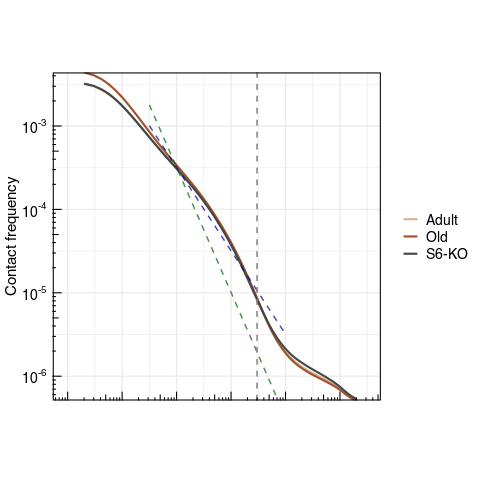

In [25]:
%%R

library(ggplot2)
library(scales)

cvd_clean <- cvd_combined %>%
  filter(is.finite(dist_bp), is.finite(balanced.avg.smoothed.agg),
         dist_bp > 0, balanced.avg.smoothed.agg > 0)
cvd_clean$condition<-replace(cvd_clean$condition, cvd_clean$condition == 'KO', 'S6-KO') 
cvd_clean$condition<-replace(cvd_clean$condition, cvd_clean$condition == 'WT', 'Adult') 

xmin <- min(cvd_clean$dist_bp)
xmax <- max(cvd_clean$dist_bp)
ymin <- min(cvd_clean$balanced.avg.smoothed.agg)
ymax <- max(cvd_clean$balanced.avg.smoothed.agg)

cvd_clean$condition <- factor(cvd_clean$condition, levels=c('Adult', 'Old', 'S6-KO'))

cvd_clean2 <- subset(cvd_clean, condition != 'S6-KO')

p1 <- ggplot(cvd_clean, aes(x = dist_bp, y = balanced.avg.smoothed.agg, color = condition)) +
  geom_line(size = 1) +
  
  geom_line(data = ref_line_1, aes(x = dist_bp, y = contact),
            color = "darkblue", linetype = "dashed", size = 0.7, inherit.aes = FALSE, alpha = 0.7) +
  geom_line(data = ref_line_15, aes(x = dist_bp, y = contact),
            color = "darkgreen", linetype = "dashed", size = 0.7, inherit.aes = FALSE, alpha = 0.7) +
  geom_vline(xintercept = 3e6, linetype = "dashed", color = "grey50", size = 0.7) +
  
  scale_y_log10(
    breaks = scales::log_breaks(base = 10, n = 5), 
    labels = scales::trans_format("log10", scales::math_format(10^.x)),
    limits = c(ymin, ymax),  
    expand = c(0, 0)          
  ) +
  scale_x_log10(
    breaks = c(1e3, 1e4, 1e5, 1e6, 1e7, 1e8, 1e9),
    labels = c(
      expression(10^3), expression(10^4), expression(10^5),
      expression(10^6), expression(10^7), expression(10^8),
      expression(10^9)
    ),
    limits = c(1e3, 3e8)  # Set explicit limits
  ) +
  annotation_logticks(sides = "bl") +
  
  labs(
    x = "",
    y = "Contact frequency",
    color = "Condition"
  ) +
  scale_colour_manual(values=c('tan', 'sienna', 'gray27')) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_blank(),
    axis.text.y       = element_text(size = 14, colour = "black"),
    axis.title.x      = element_text(size = 15, colour = "black"),
    axis.title.y      = element_text(size = 15, colour = "black"),
    legend.text       = element_text(size = 14),
    legend.title      = element_blank(),
    panel.border      = element_rect(colour = "black", fill = NA, size = 1),
    aspect.ratio      = 1,
    #legend.position   = "none",
    plot.margin = margin(t = 7, r = 5, b = -7, l = 5, unit = "pt")
  )

p1

### Plot ratio of scalings 

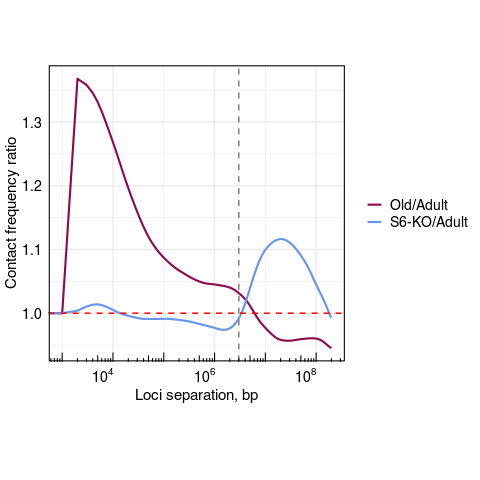

In [27]:
%%R

compute_normalized_ratio <- function(df, numerator, denominator) {
  num_data <- df %>% filter(condition == numerator)
  den_data <- df %>% filter(condition == denominator)
  
  merged <- inner_join(num_data, den_data, by = "dist_bp", suffix = c("_num", "_den")) %>%
    mutate(ratio = balanced.avg.smoothed.agg_num / balanced.avg.smoothed.agg_den)
  
  # Avoid division by zero or NaN
  merged$ratio[!is.finite(merged$ratio)] <- 1
  
  # Normalize to a reference point
  x_ref <- sort(unique(merged$dist_bp))[2]
  ref_value <- merged$ratio[which.min(abs(merged$dist_bp - x_ref))]
  merged <- merged %>%
    mutate(norm_ratio = ratio / ref_value,
           comp = paste0(numerator, "/", denominator))
  return(merged)
}

r1 <- compute_normalized_ratio(cvd_combined, "S6-KO", "Adult")
r2 <- compute_normalized_ratio(cvd_combined, "Old", "Adult")
ratios_df <- bind_rows(r1, r2)


p2 <- ggplot(ratios_df, aes(x = dist_bp, y = norm_ratio, color = comp)) +
  geom_line(size = 1) +  
  scale_x_log10(
    breaks = c(1e4, 1e6, 1e8),
    labels = c(
      expression(10^4), 
      expression(10^6), expression(10^8)
    ),
    limits = c(1e3, 2e8)  # Match limits from p1
  ) +
  geom_vline(xintercept = 3e6, linetype = "dashed", color = "grey50", size = 0.7) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red", size = 0.7) +
  annotation_logticks(
    sides = "b",          # Ticks only on bottom (x-axis)
  ) +
  # Theme and labels (matching previous plots)
  labs(
    x = "Loci separation, bp",  # Consistent x-axis label
    y = "Contact frequency ratio",                 # Keep your custom y-axis label
    color = "Comp"               # Legend title (capitalize if needed)
  ) +
  scale_color_manual(values=c('deeppink4', 'cornflowerblue')) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(size = 14, colour = "black", hjust = 1),
    axis.text.y = element_text(size = 14, colour = "black"),
    axis.title.x = element_text(size = 15, colour = "black"),
    axis.title.y = element_text(size = 15, colour = "black"),
    legend.text = element_text(size = 14),
    legend.title = element_blank(),
    panel.border = element_rect(colour = "black", fill = NA, size = 1),
    aspect.ratio = 1,
    #legend.position = "none",
    plot.margin = margin(t = -7, r = 5, b = 5, l = 5, unit = "pt")
  )

p2
